# One-Class Support Vector Machines

### and Stochastic Gradient Decent One-Class Support Vector Machines

This notebook employs the use of OCSVM, a unsupervised machine learning approach, to identify outliers aka fraud within the Unified dataset. 

The traditional SVM had issues in handling the imbalanced dataset, where it failed to diferentiate fraud from non-fraud cases. 


Link: https://www.geeksforgeeks.org/machine-learning/understanding-one-class-support-vector-machines/

Link: https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html

In [1]:
## Libraries to be used...

# To see how long the model runs for..
import time

# Handle arrays and tables. Also visuals.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# OCSVM
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

#SGDOneClassSVM
from sklearn.linear_model import SGDOneClassSVM

# Undersampling 
from imblearn.under_sampling import RandomUnderSampler

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold

# FDSU
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import LinearSVC

# Evaluate model performance
from sklearn.metrics import (precision_score, recall_score, f1_score)
from sklearn.metrics import accuracy_score

# Visual
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Suppress all ConvergenceWarnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Looking at the data

In [2]:
# Load the Dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/gold/unified_dataset.csv")

print(f"Shape of the file: {df.shape}")


# Display first few rows
print("\nFirst few rows:")
print(df.head())

Shape of the file: (140827, 69)

First few rows:
          npi rfrg_prvdr_state_abrvtn  target  avg_suplr_mdcr_pymt_amt_sum  \
0  1003000597                      OK       0                     1.692306   
1  1003000597                      OK       0                    23.833223   
2  1003000902                      KY       0                   155.711788   
3  1003000902                      KY       0                    67.361088   
4  1003000902                      KY       0                    40.802223   

   avg_suplr_mdcr_pymt_amt_min  avg_suplr_mdcr_pymt_amt_max  \
0                     1.692306                     1.692306   
1                     0.112054                     8.331875   
2                     0.087436                    82.163333   
3                     0.028794                    38.227500   
4                     0.098643                    24.145333   

   tot_suplr_nonrntl_hcpcs_cds  tot_suplrs_median  tot_suplrs_min  \
0                          1.0    

In [3]:
# Listing the column names....
print ("The columns in the dataset are as follows:\n")
df.columns.to_list()

The columns in the dataset are as follows:



['npi',
 'rfrg_prvdr_state_abrvtn',
 'target',
 'avg_suplr_mdcr_pymt_amt_sum',
 'avg_suplr_mdcr_pymt_amt_min',
 'avg_suplr_mdcr_pymt_amt_max',
 'tot_suplr_nonrntl_hcpcs_cds',
 'tot_suplrs_median',
 'tot_suplrs_min',
 'tot_suplr_clms_min',
 'tot_suplr_srvcs_min',
 'tot_suplrs_max',
 'tot_suplr_benes_max',
 'tot_suplr_clms_max',
 'accessories_for_oxygen_delivery_devices',
 'breathing_aids',
 'hospital_beds_and_associated_supplies',
 'humidifiers_and_nebulizers_with_related_equipment',
 'infusion_pumps_and_supplies',
 'other_supplies_including_diabetes_supplies_and_contraceptives',
 'oxygen_delivery_systems_and_related_supplies',
 'wheelchairs_components_and_accessories',
 'bene_race_api_cnt',
 'bene_dual_cnt',
 'bene_cc_bh_tobacco_v1_pct',
 'bene_cc_bh_alz_non_alzdem_v2_pct',
 'bene_cc_bh_anxiety_v1_pct',
 'bene_cc_bh_schizo_oth_psy_v1_pct',
 'bene_cc_ph_asthma_v2_pct',
 'bene_cc_ph_ckd_v2_pct',
 'bene_cc_ph_copd_v2_pct',
 'bene_cc_ph_diabetes_v2_pct',
 'bene_cc_ph_hf_non_ihd_v2_pct',
 '

In [4]:
# Looking at count of npis grouping by "target"...
df.groupby(df['target']).count()

,npi,rfrg_prvdr_state_abrvtn,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplrs_median,tot_suplrs_min,tot_suplr_clms_min,tot_suplr_srvcs_min,...,tot_suplr_benes_sum_zscore_by_type,tot_suplr_srvcs_max_zscore,total_payment_zscore_by_type,bene_avg_age_zscore_by_type,bene_avg_risk_scre_zscore_by_type,submitted_to_standardized_ratio_zscore,submitted_to_standardized_ratio_zscore_by_type,claims_per_bene_zscore_by_type,services_per_bene_zscore_by_type,benes_per_supplier_zscore_by_type
target,,,,,,,,,,,,,,,,,,,,,
0,140771,140771,140771,140771,140771,140771,140771,140771,140771,140771,...,140771,140771,140771,140771,140771,140771,140771,140771,140771,140771
1,56,56,56,56,56,56,56,56,56,56,...,56,56,56,56,56,56,56,56,56,56


In [5]:
# Checking for Nulls i neach column..

print(df.isnull().sum()[df.isnull().sum() > 0])

# No nulls?


Series([], dtype: int64)


In [6]:
# String/categorical columns
print(df.dtypes[df.dtypes == 'object'])

# Boolean columns (if any)
print(df.dtypes[df.dtypes == 'bool'])  

rfrg_prvdr_state_abrvtn    object
specialty_type             object
specialty                  object
dtype: object
Series([], dtype: object)


# Attempt - 1

## Initial Setup

In [3]:
# Define key column names
target_col = 'target'

# Random state for reproducibility
random_state = 42

# Columns to exclude from features
exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn',
    'specialty_type', 'specialty'
]

df_clean = df.drop(columns = exclude_cols).dropna().reset_index(drop=True)
print(f"\nNo. of Entires after cleanup: {len(df_clean):,}")

# Spliting the data
X = df_clean.loc[:,df_clean.columns!='target']
y = df_clean[target_col]

X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)

# Standardizing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nNo. of Entires in training data: {len(X_train_scaled):,}")
print(f"\nNo. of Entires in test data: {len(X_test_scaled):,}")


No. of Entires after cleanup: 140,827

No. of Entires in training data: 112,661

No. of Entires in test data: 28,166


In [4]:
# Checking....
X_train_scaled

array([[-0.42685789, -0.10291195, -0.41029781, ..., -0.54026897,
        -0.37307067,  0.03494069],
       [-0.42051903, -0.1521526 , -0.40151513, ..., -0.03913026,
        -0.03071013, -0.17956838],
       [-0.24014312, -0.1519616 , -0.10521561, ..., -0.62688553,
        -0.35681126, -0.2016502 ],
       ...,
       [-0.31175865, -0.15441315, -0.3185159 , ...,  0.82928641,
         4.2363931 ,  0.05238366],
       [-0.40848273, -0.1552802 , -0.39374427, ..., -0.52813538,
         0.00597579, -0.61270381],
       [ 0.2759095 , -0.15191036,  0.30537783, ...,  1.03186122,
        -0.17300724, -0.18765643]])

In [50]:
# Performance evaluation function
def evaluate_predictions(y_true, y_pred):
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0)
        #'pr_auc': average_precision_score(y_true, y_pred_proba),
        #'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

Cant evaluate the model using AUC-ROC since the model doesnt support it.
    
Link = https://stackoverflow.com/questions/28022081/how-to-calculate-auc-for-one-class-svm-in-python

There is a workaround which will be looked into.

## Model Training, testing and evaluation using default parameters (no pipeline)

This portion of the notebook is to see the performance of the model using its default parameters.

In [51]:

start = time.time()

# Model training 
ocsvm_v1 = OneClassSVM()
ocsvm_v1.fit(X_train_scaled)

# prediction on training data
y_pred = ocsvm_v1.predict(X_train_scaled)
y_pred = np.where(y_pred == 1, 1, 0)

# Evaluation 
metrics = evaluate_predictions(y_train, y_pred)
print(f"\nTRAINING DATASET METRICS")
print('-' * 10)
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")

end = time.time()

print(f"\nTotal runtime of the program is {end - start:.4f} seconds")



TRAINING DATASET METRICS
----------
  Precision : 0.0003
  Recall    : 0.3696
  F1 Score  : 0.0006

Total runtime of the program is 1260.8864 seconds



TESTING DATASET METRICS
----------
  Precision : 0.0003
  Recall    : 0.4000
  F1 Score  : 0.0006

Total runtime of the program is 76.9630 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67     28156
       Fraud       0.00      0.40      0.00        10

    accuracy                           0.50     28166
   macro avg       0.50      0.45      0.33     28166
weighted avg       1.00      0.50      0.67     28166



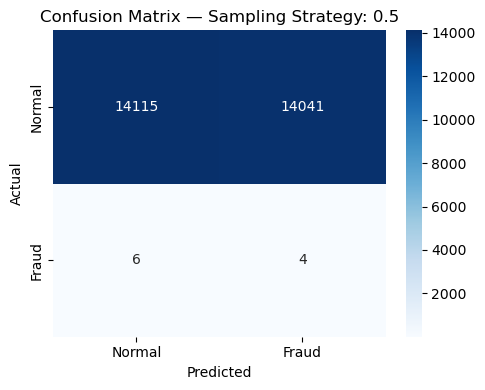

In [52]:
# prediction on test data
start = time.time()
y_pred_test = ocsvm_v1.predict(X_test_scaled)
y_pred_test = np.where(y_pred_test == 1, 1, 0)

# Evaluation 
metrics = evaluate_predictions(y_test, y_pred_test)
print(f"\nTESTING DATASET METRICS")
print('-' * 10)
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")

end = time.time()

print(f"\nTotal runtime of the program is {end - start:.4f} seconds")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fraud']))

# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix — Sampling Strategy: {numm}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Results:

The metrics are really bad for both evaluations. So lots of Underfitting that can be fixed with hyperparameter tuning. 

Another issue is the execution time where it took close to 30 mins for the subpar results. Moreoever, it took 7+ hours with hyperparameter tuning while still being stuck in the first fold. 

A work around to this is Undersampling, which will reduce the imbalance and greatly improve execution time due to smaller dataset size. 

# Attempt - 2

This portion of the notebook intends to address the issues faced above using a pipeline.

## Initial setup for the pipeline

In this attempt we will be testing a variety of parameters to see if models ability to detect outliers can improve within a pipeline.

### The parameters: 

1) nu - controls the upper and lower bound. Bascially tells that the model expects at most % of outliers from the data (upper) and aleast % of training data to be used as support vectors (lower). Higher the value, the more sensitive it is to outliers.

2) kernel - defines the shape of the boundry/hyperplane

3) gamma - controls how far the influence of a point is going to be. Higher the gamma, tigter the bubble. (Think of it how far points can see, and accourdingly maps out a boundry)

4) coef0 - shifts the boundry. Higher the value, the more lenient it becomes.

5) degree - controls the number of degrees a boundry will have. Higher the number the more complex the boundry becomes, which can in turn, result in overfitting. 

In [7]:
# Version - 1 of param_grid_ocsvm
param_grid_ocsvm = [
    {
        'ocsvm__kernel' : ['linear'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
    },
    {
        'ocsvm__kernel' : ['rbf'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
    },
    {
        'ocsvm__kernel' : ['sigmoid'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],
        'ocsvm__coef0'  : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
    },
    {
        'ocsvm__kernel' : ['poly'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.1, 0.01, 0.001],
        'ocsvm__degree' : [2, 3, 4, 5],
        'ocsvm__coef0'  : [0.0, 0.1, 0.5, 1.0, 2.0]
    }
]

In [6]:
# Version - 2 of param_grid_ocsvm
param_grid_ocsvm = [
   
    {
        'ocsvm__kernel': ['linear'],
        'ocsvm__nu': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    {
        'ocsvm__kernel': ['rbf'],
        'ocsvm__nu': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'ocsvm__gamma': ['scale', 'auto', 1, 0.8, 0.5, 0.2, 0.1, 0.08, 0.05, 0.02, 0.01,0.005, 0.001, 0.0005, 0.0001, 0.00001]
    },
    {
        'ocsvm__kernel': ['sigmoid'],
        'ocsvm__nu': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'ocsvm__gamma': ['scale', 'auto', 1, 0.8, 0.5, 0.2, 0.1, 0.08, 0.05, 0.02, 0.01,0.005, 0.001, 0.0005, 0.0001],
        'ocsvm__coef0': [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
    },
    {
        'ocsvm__kernel': ['poly'],
        'ocsvm__nu': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'ocsvm__gamma': ['scale', 'auto', 0.5, 0.2, 0.1, 0.08, 0.05, 0.02, 0.01, 0.005, 0.001],
        'ocsvm__degree': [2, 3, 4, 5, 6],
        'ocsvm__coef0': [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
    }
]

### Funtions that will be used in this attempt:

In [7]:
# Performance evaluation function
def evaluate_predictions(y_true, y_pred):
    metrics = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

In [8]:
# Custome scorer for the pipeline that that it came compare which is the best
def ocsvm_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    y_pred = np.where(y_pred == 1, 1, 0)
    metrics = evaluate_predictions(y, y_pred) # Gets the F1 score from existing function 
    return metrics['f1_score']

In [9]:
# Funtion to split and undersample the data. 
def Xysplitter (numm, df):
    # Define key column names
    target_col = 'target'

    # Random state for reproducibility
    random_state = 42

    # Columns to exclude from features
    exclude_cols = ['npi', 'rfrg_prvdr_state_abrvtn','specialty_type', 'specialty']

    df_clean = df.drop(columns = exclude_cols).dropna().reset_index(drop=True)
    #print(f"\nNo. of Entires after cleanup: {len(df_clean):,}")

    # Spliting the data
    X = df_clean.loc[:,df_clean.columns!='target']
    y = df_clean[target_col]

    X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = random_state)

    rus = RandomUnderSampler(sampling_strategy=numm, random_state=random_state)
    X_train, y_train = rus.fit_resample(X_train, y_train)


    print(f"No. of Entires in training data: {len(X_train):,}")
    print(f"No. of Entires in test data: {len(X_test):,}\n")

    return X_train, X_test, y_train,  y_test

Sampling Strategy set as : 0.05
No. of Entires in training data: 945
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.2, 'ocsvm__degree': 5, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.12}
Best F1: 0.1028
Total runtime of the program on training data is 336.0497 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.7273
F1 Score: 0.0008
Total runtime of the program on test data is 0.1238 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.29      0.44     28155
       Fraud       0.00      0.73      0.00        11

    accuracy                           0.29     28166
   macro avg       0.50      0.51      0.22     28166
weighted avg       1.00      0.29      0.44     28166



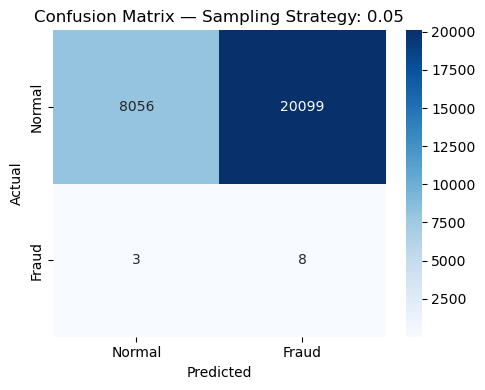

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.06
No. of Entires in training data: 795
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.0, 'ocsvm__degree': 4, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.12}
Best F1: 0.1000
Total runtime of the program on training data is 291.8389 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0006
Recall: 0.5455
F1 Score: 0.0013
Total runtime of the program on test data is 0.0901 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.67      0.80     28155
       Fraud       0.00      0.55      0.00        11

    accuracy                           0.67     28166
   macro avg       0.50      0.61      0.40     28166
weighted avg       1.00      0.67      0.80     28166



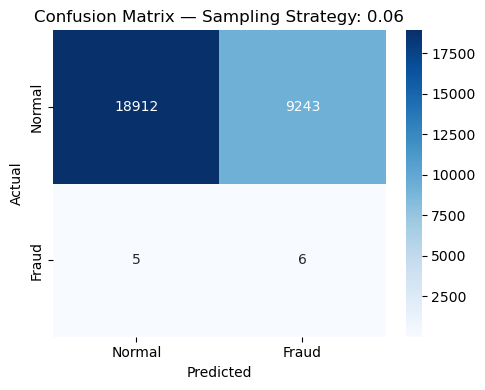

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.07
No. of Entires in training data: 687
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.2, 'ocsvm__degree': 6, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.7}
Best F1: 0.1111
Total runtime of the program on training data is 265.4377 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0008
Recall: 0.3636
F1 Score: 0.0017
Total runtime of the program on test data is 0.2997 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.83      0.91     28155
       Fraud       0.00      0.36      0.00        11

    accuracy                           0.83     28166
   macro avg       0.50      0.60      0.45     28166
weighted avg       1.00      0.83      0.91     28166



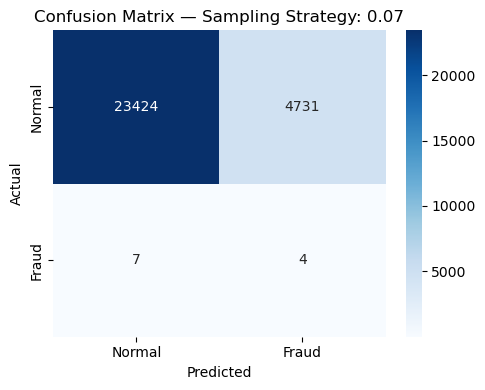

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.08
No. of Entires in training data: 607
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.5, 'ocsvm__degree': 2, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.01}
Best F1: 0.1157
Total runtime of the program on training data is 245.2314 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.6364
F1 Score: 0.0007
Total runtime of the program on test data is 0.1006 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.31      0.48     28155
       Fraud       0.00      0.64      0.00        11

    accuracy                           0.31     28166
   macro avg       0.50      0.48      0.24     28166
weighted avg       1.00      0.31      0.48     28166



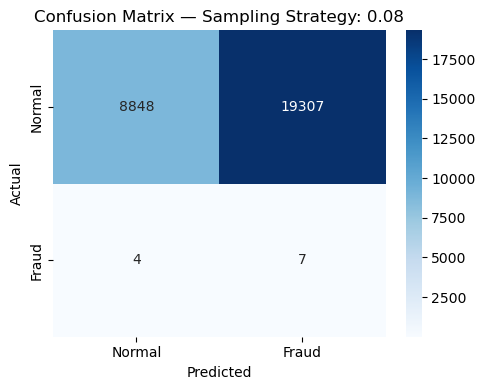

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.09
No. of Entires in training data: 545
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.0, 'ocsvm__degree': 4, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.16}
Best F1: 0.1287
Total runtime of the program on training data is 232.5427 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0006
Recall: 0.5455
F1 Score: 0.0013
Total runtime of the program on test data is 0.0901 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.66      0.80     28155
       Fraud       0.00      0.55      0.00        11

    accuracy                           0.66     28166
   macro avg       0.50      0.60      0.40     28166
weighted avg       1.00      0.66      0.80     28166



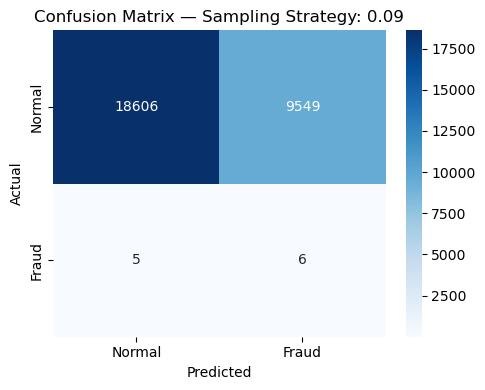

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.1
No. of Entires in training data: 495
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.0, 'ocsvm__degree': 4, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.2}
Best F1: 0.1318
Total runtime of the program on training data is 223.3717 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0006
Recall: 0.5455
F1 Score: 0.0012
Total runtime of the program on test data is 0.0930 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.66      0.79     28155
       Fraud       0.00      0.55      0.00        11

    accuracy                           0.66     28166
   macro avg       0.50      0.60      0.40     28166
weighted avg       1.00      0.66      0.79     28166



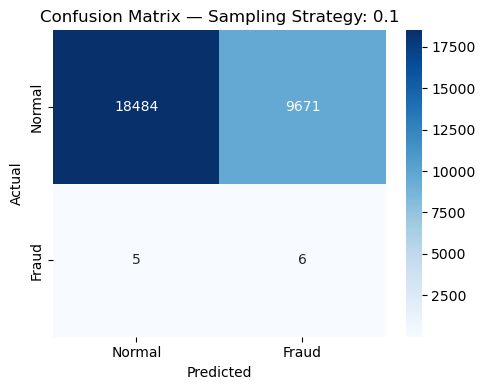

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.2
No. of Entires in training data: 270
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.0, 'ocsvm__gamma': 0.5, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.02}
Best F1: 0.1837
Total runtime of the program on training data is 191.3677 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 1.0000
F1 Score: 0.0008
Total runtime of the program on test data is 0.0330 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.01      0.01     28155
       Fraud       0.00      1.00      0.00        11

    accuracy                           0.01     28166
   macro avg       0.50      0.50      0.01     28166
weighted avg       1.00      0.01      0.01     28166



/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.13333333 0.13866667 0.1260274  ... 0.11343284 0.10322581        nan]
  warnings.warn(


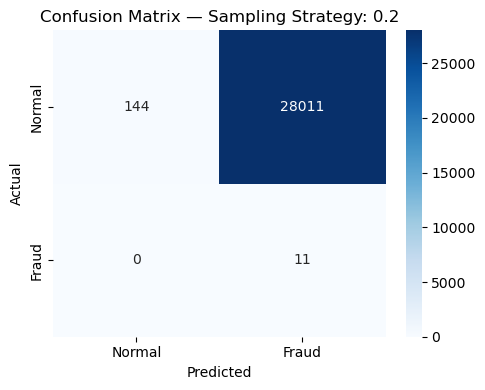

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.3
No. of Entires in training data: 195
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.0, 'ocsvm__gamma': 0.08, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.02}
Best F1: 0.2585
Total runtime of the program on training data is 183.8693 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 1.0000
F1 Score: 0.0008
Total runtime of the program on test data is 0.0305 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.02      0.03     28155
       Fraud       0.00      1.00      0.00        11

    accuracy                           0.02     28166
   macro avg       0.50      0.51      0.02     28166
weighted avg       1.00      0.02      0.03     28166



/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.18720612 0.1676951  0.19103261 ... 0.12142857 0.10566038        nan]
  warnings.warn(


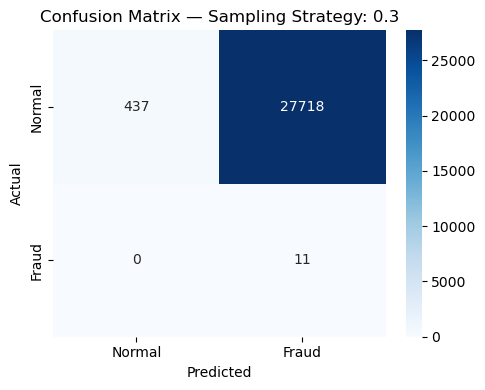

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.4
No. of Entires in training data: 157
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 0.05, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.03}
Best F1: 0.3376
Total runtime of the program on training data is 180.1979 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.9091
F1 Score: 0.0009
Total runtime of the program on test data is 0.0593 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.18      0.30     28155
       Fraud       0.00      0.91      0.00        11

    accuracy                           0.18     28166
   macro avg       0.50      0.54      0.15     28166
weighted avg       1.00      0.18      0.30     28166



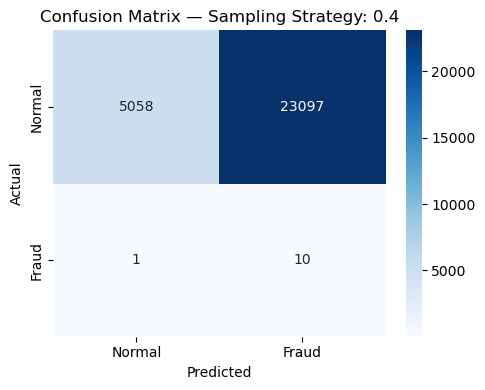

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.5
No. of Entires in training data: 135
No. of Entires in test data: 28,166

Fitting 5 folds for each of 21242 candidates, totalling 106210 fits


/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
4085 fits failed out of a total of 106210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4085 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/conda/lib/python3.11/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/sklearn/pipeline.py", line 663, in fit
    self._final_estimator.fit(Xt,


Best params: {'ocsvm__coef0': 5.0, 'ocsvm__gamma': 0.5, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.04}
Best F1: 0.3674
Total runtime of the program on training data is 178.2319 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0003
Recall: 0.7273
F1 Score: 0.0006
Total runtime of the program on test data is 0.0335 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.08      0.14     28155
       Fraud       0.00      0.73      0.00        11

    accuracy                           0.08     28166
   macro avg       0.50      0.40      0.07     28166
weighted avg       1.00      0.08      0.14     28166



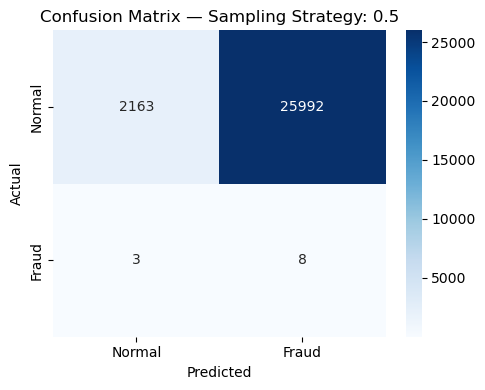

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------






In [10]:
# sampling_strategy values to check
sample_strat = [0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5]

for numm in sample_strat:
    start = time.time()
    print(f"Sampling Strategy set as : {numm}")
    X_train, X_test, y_train,  y_test = Xysplitter(numm, df)
    # Building pipeline
    pipeline = Pipeline([('scaler', StandardScaler()), ('ocsvm', OneClassSVM())])

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid_ocsvm,
        scoring = ocsvm_scorer,
        cv = 5,
        n_jobs = -1,
        verbose = 1
    )

    grid_search.fit(X_train, y_train)
    print(f"\nBest params: {grid_search.best_params_}")
    print(f"Best F1: {grid_search.best_score_:.4f}")

    end = time.time()
    print(f"Total runtime of the program on training data is {end - start:.4f} seconds")
    
    start = time.time()
    # Evaluate on test set
    best_pipeline = grid_search.best_estimator_
    y_pred_test = best_pipeline.predict(X_test)
    y_pred_test = np.where(y_pred_test == 1, 1, 0)

    metrics = evaluate_predictions(y_test, y_pred_test)
    print(f"\nTEST DATASET METRICS")
    print('-' * 20)
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    end = time.time()
    print(f"Total runtime of the program on test data is {end - start:.4f} seconds\n")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fraud']))

    # Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix — Sampling Strategy: {numm}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    
    print('-' * 150)
    print('-' * 150)
    print('\n')
    print('\n')
    


### Results

### Issues/Observations:

1) Some of the results are classifying most of the test data as fraud.
2) Certain parameters are way to aggressive and result in 0 precisison/recall/f1 score. 
3) The best parameters on training data dont seem to generalize well on test data. 
4) Gamma values like 1 and 0.8 might be a bit too big for the data even after standardization. 

# Attempt - 3
In this portion of the script, makes changes to the above code. 

In [11]:
# Version - 3 of param_grid_ocsvm
param_grid_ocsvm = [
    {
        'ocsvm__kernel' : ['linear'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
        # linear is simple, nu range is enough
    },
    {
        'ocsvm__kernel' : ['rbf'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.1, 0.01, 0.005, 0.001, 0.0005, 0.0001]
        # removed 1, 0.8, 0.5, 0.2 as these seem to cause the ValueError
    },
    {
        'ocsvm__kernel' : ['sigmoid'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.1, 0.01, 0.001, 0.0001,0.00001],
        'ocsvm__coef0'  : [0.0, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0]
        # removed large gamma values, trimmed out coef0 as well
    },
    {
        'ocsvm__kernel' : ['poly'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.01, 0.001],
        'ocsvm__degree' : [2, 3],               # removed 4, 5, 6 as they caused overfitting on small data
        'ocsvm__coef0'  : [0.0, 0.1, 0.5, 1.0] # removed quite a few vlaues
    }
]

In [15]:
# Version - 4 of param_grid_ocsvm
# Minor alterations

param_grid_ocsvm = [
    {
        'ocsvm__kernel' : ['linear'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    },
    {
        'ocsvm__kernel' : ['rbf'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.1, 0.05, 0.01, 0.005, 0.001, 0.0001]
    },
    {
        'ocsvm__kernel' : ['sigmoid'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.1, 0.05, 0.01, 0.001, 0.0001],
        'ocsvm__coef0'  : [0.0, 0.1, 0.5, 1.0, 2.0, 3.0]
    },
    {
        'ocsvm__kernel' : ['poly'],
        'ocsvm__nu'     : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__gamma'  : ['scale', 'auto', 0.05, 0.01, 0.005, 0.001],
        # Added few more gamma values
        'ocsvm__degree' : [2, 3, 4],
        # Added 4 for testing purposes
        'ocsvm__coef0'  : [0.0, 0.1, 0.5, 1.0, 2.0]
        # Added 2.0 for testing purposes
    }
]

Sampling Strategy set as : 0.07
No. of Entires in training data: 687
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 2.0, 'ocsvm__degree': 2, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.5}
Best F1: 0.1069
Total runtime of the program on training data is 20.9384 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.5455
F1 Score: 0.0009
Total runtime of the program on test data is 0.2428 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.51      0.67     28155
       Fraud       0.00      0.55      0.00        11

    accuracy                           0.51     28166
   macro avg       0.50      0.53      0.34     28166
weighted avg       1.00      0.51      0.67     28166



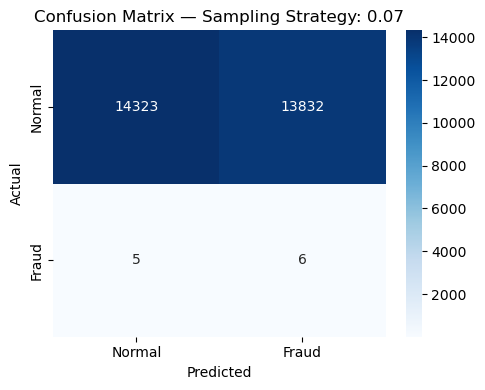

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.08
No. of Entires in training data: 607
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.5, 'ocsvm__degree': 2, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.01}
Best F1: 0.1157
Total runtime of the program on training data is 18.2580 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.6364
F1 Score: 0.0007
Total runtime of the program on test data is 0.1015 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.31      0.48     28155
       Fraud       0.00      0.6

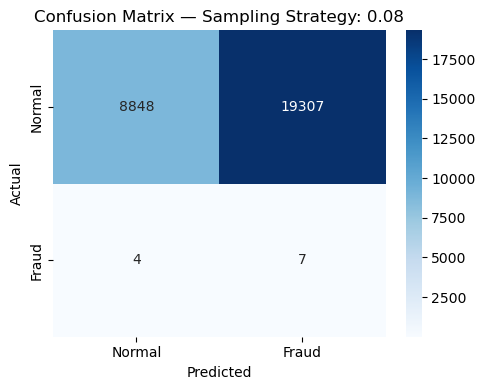

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.09
No. of Entires in training data: 545
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.0, 'ocsvm__degree': 4, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.15}
Best F1: 0.1235
Total runtime of the program on training data is 17.4578 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0007
Recall: 0.5455
F1 Score: 0.0014
Total runtime of the program on test data is 0.0843 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.70      0.82     28155
       Fraud       0.00      0.5

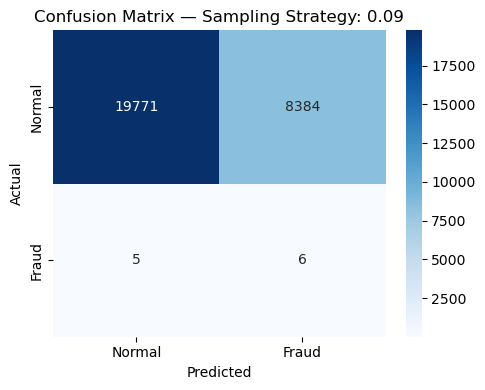

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.1
No. of Entires in training data: 495
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.0, 'ocsvm__degree': 4, 'ocsvm__gamma': 0.005, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.2}
Best F1: 0.1318
Total runtime of the program on training data is 16.6690 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0006
Recall: 0.5455
F1 Score: 0.0012
Total runtime of the program on test data is 0.0965 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.66      0.79     28155
       Fraud       0.00      0.55 

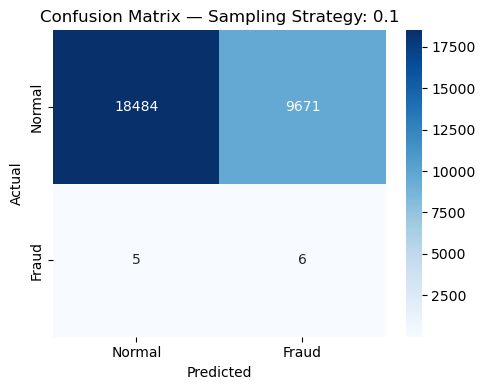

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.2
No. of Entires in training data: 270
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 2.0, 'ocsvm__gamma': 0.01, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.01}
Best F1: 0.1837
Total runtime of the program on training data is 14.4684 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 1.0000
F1 Score: 0.0008
Total runtime of the program on test data is 0.0291 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.02      0.03     28155
       Fraud       0.00      1.00      0.00        

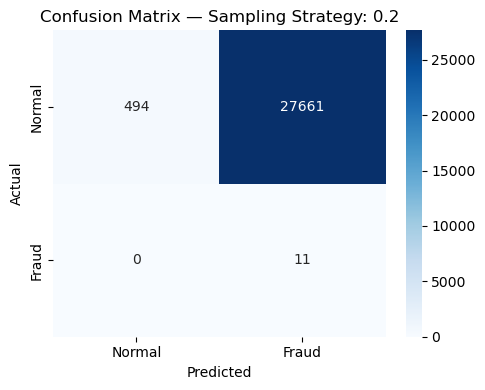

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.3
No. of Entires in training data: 195
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.0, 'ocsvm__gamma': 0.05, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.01}
Best F1: 0.2533
Total runtime of the program on training data is 13.8972 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 1.0000
F1 Score: 0.0008
Total runtime of the program on test data is 0.0314 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.02      0.04     28155
       Fraud       0.00      1.00      0.00        

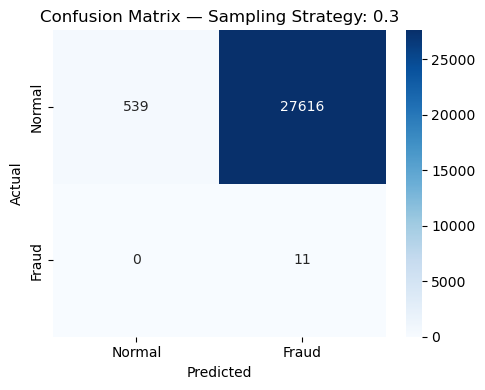

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.4
No. of Entires in training data: 157
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.0, 'ocsvm__gamma': 0.1, 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.05}
Best F1: 0.3300
Total runtime of the program on training data is 13.6394 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 1.0000
F1 Score: 0.0008
Total runtime of the program on test data is 0.0350 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.01      0.02     28155
       Fraud       0.00      1.00      0.00        1

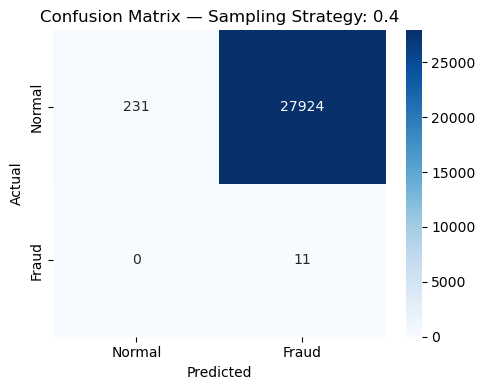

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------




Sampling Strategy set as : 0.5
No. of Entires in training data: 135
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1551 candidates, totalling 7755 fits

Best params: {'ocsvm__coef0': 0.0, 'ocsvm__gamma': 'scale', 'ocsvm__kernel': 'sigmoid', 'ocsvm__nu': 0.01}
Best F1: 0.3562
Total runtime of the program on training data is 13.4515 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0004
Recall: 0.9091
F1 Score: 0.0008
Total runtime of the program on test data is 0.0364 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.10      0.18     28155
       Fraud       0.00      0.91      0.00     

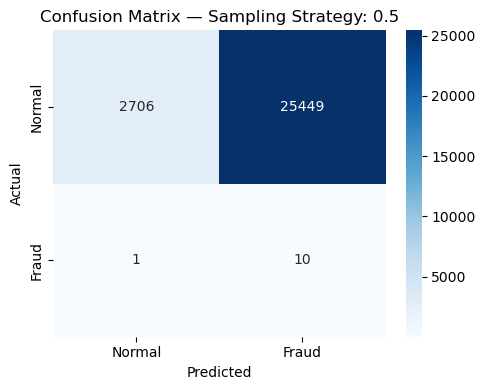

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------






In [16]:
# sampling_strategy values to check
sample_strat = [0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5] # Tries a variety of resonable ratios  

for numm in sample_strat:
    start = time.time()
    print(f"Sampling Strategy set as : {numm}")
    X_train, X_test, y_train,  y_test = Xysplitter(numm, df)
    # Building pipeline
    pipeline = Pipeline([('scaler', StandardScaler()), ('ocsvm', OneClassSVM())])

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid_ocsvm,
        scoring = ocsvm_scorer,
        cv = 5,
        n_jobs = -1,
        verbose = 1
    )

    grid_search.fit(X_train, y_train)
    print(f"\nBest params: {grid_search.best_params_}")
    print(f"Best F1: {grid_search.best_score_:.4f}")

    end = time.time()
    print(f"Total runtime of the program on training data is {end - start:.4f} seconds")
    
    start = time.time()
    # Evaluate on test set
    best_pipeline = grid_search.best_estimator_
    y_pred_test = best_pipeline.predict(X_test)
    y_pred_test = np.where(y_pred_test == 1, 1, 0)

    metrics = evaluate_predictions(y_test, y_pred_test)
    print(f"\nTEST DATASET METRICS")
    print('-' * 20)
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    end = time.time()
    print(f"Total runtime of the program on test data is {end - start:.4f} seconds\n")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fraud']))

    # Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix — Sampling Strategy: {numm}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    
    print('-' * 150)
    print('-' * 150)
    print('\n')
    print('\n')

### Result

# Attempt - 4

In this portion of the script, we will be testing out the performance of the model with FDUS.

Define the FDUS undersampler based on Zhou et al. (2024). The algorithm:

- Fits a separating hyperplane using either Logistic Regression or Linear SVM
- Clusters the majority class with K-Means
- Applies spatial compression to focus on boundary regions
- Uses weighted sampling where points closer to the decision boundary have higher selection probability

In [17]:
# Data Prep work

# Define key column names
target_col = 'target'
npi_col = 'npi'

# Random state for reproducibility
random_state = 42

# FDUS configuration
fdus_ratio = 5.0
fdus_alpha = 0.5
fdus_n_clusters = 30

# Cross-validation folds
n_cv_folds = 5

# Columns to exclude from features
exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn', 'year', 'target',
    'og_specialty_name', 'first_payment_date', 'last_payment_date',
    'specialty_type', 'specialty'
]

# Identify feature columns (numeric only, excluding metadata)
exclude_cols_set = exclude_cols
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols_set]

print(f"Number of features kept: {len(feature_cols)}")

# Clean the dataset
df_clean = df[feature_cols + [target_col, npi_col]].dropna().reset_index(drop=True)
print(f"\nNo. of Entires after cleanup: {len(df_clean):,}")

# Separate features, target, and groups
X = df_clean[feature_cols].values
y = df_clean[target_col].values
groups = df_clean[npi_col].values

print(f"\nClass Distribution:")
print(f"  Non-Fraud (0): {(y == 0).sum():,}")
print(f"  Fraud (1): {(y == 1).sum()}")

Number of features kept: 64

No. of Entires after cleanup: 140,827

Class Distribution:
  Non-Fraud (0): 140,771
  Fraud (1): 56


In [18]:
# FDUS with Logistic Regression 

class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling

    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """

    def __init__(self, n_clusters=30, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None

    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using logistic regression"""
        clf = LogisticRegression(max_iter=500, random_state=self.random_state,
                                  solver='saga', n_jobs=-1)
        clf.fit(X, y)
        return clf

    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances

    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)

        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)

        samples_per_cluster = max(1, n_samples_target // self.n_clusters)

        selected_indices = []

        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[cluster_indices]

            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min

            # Spatial compression: only sample from boundary region
            COMPRESSION_THRESHOLD = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= COMPRESSION_THRESHOLD
            boundary_indices = cluster_indices[boundary_mask]

            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices

            boundary_distances = distances[boundary_indices]

            # Weighted sampling: closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()

            n_to_sample = min(samples_per_cluster, len(boundary_indices))

            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices,
                    size=n_to_sample,
                    replace=False,
                    p=weights
                )
                selected_indices.extend(sampled)

        return np.array(selected_indices)

    def fit_resample(self, X_majority, X_minority, verbose=True):
        """Apply FDUS undersampling"""
        n_minority = len(X_minority)
        n_majority = len(X_majority)

        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])

        # Step 1: Fit hyperplane
        if verbose:
            print(f"    FDUS: Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        if verbose:
            print("done")

        # Step 2: Compute distances
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)

        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        if verbose:
            print(f"    FDUS: Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx = self._weighted_cluster_undersample(X_majority, distances, n_target)
        if verbose:
            print("done")

        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])

        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]

        if verbose:
            print(f"    FDUS: {len(X_resampled):,} samples "
                  f"({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")

        return X_resampled, y_resampled

print("FDUS class defined")

FDUS class defined


In [19]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------

In [20]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS + OCSVM GRID SEARCH
######################################################################

# Outer CV groups by NPI — same provider never leaks across train/test
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Result storage
fold_metrics     = []
fold_best_params = []
fold_models      = []
all_test_indices = []
all_test_probas  = []
all_test_labels  = []

pipeline = Pipeline([('ocsvm', OneClassSVM())])

start_time = time.time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1} of {n_cv_folds}")
    print(f"{'='*60}")

    # Slice train / test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"  Train : {len(X_train):,} rows  |  fraud={y_train.sum()}  non-fraud={(y_train==0).sum():,}")
    print(f"  Test  : {len(X_test):,} rows   |  fraud={y_test.sum()}  non-fraud={(y_test==0).sum():,}")

    # Skip if no fraud in test — nothing meaningful to evaluate
    if y_test.sum() == 0:
        print("  SKIPPED — no fraud cases in test fold")
        continue

    # ── Step 1: Scale features ───────────────────────────────────────
    # Always fit scaler on training data only to avoid data leakage
    t = time.time()
    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"  [1/4] Scaling          ... done ({time.time()-t:.1f}s)")

    # ── Step 2: FDUS undersampling ───────────────────────────────────
    # Undersample majority class (non-fraud) using boundary-aware sampling
    t            = time.time()
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters   = fdus_n_clusters,
        alpha        = fdus_alpha,
        target_ratio = fdus_ratio,
        random_state = random_state
    )
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [2/4] FDUS resampling  ... done ({time.time()-t:.1f}s)")

    # ── Step 3: Grid search for best SVM hyperparameters ────────────
    # Inner CV runs only on the resampled training data
    t        = time.time()
    inner_cv = StratifiedKFold(
        n_splits     = min(3, int(y_train_resampled.sum())),
        shuffle      = True,
        random_state = random_state
    )

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid_ocsvm,
        scoring    = ocsvm_scorer,
        cv         = inner_cv,
        n_jobs     = -1,
        verbose    = 0
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [3/4] Grid search      ... done ({time.time()-t:.1f}s)")

    best_svm = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_svm))

    print(f"  Best F1 score : {grid_search.best_score_:.4f}")
    print(f"  Best params          : {grid_search.best_params_}")

    # ── Step 4: Evaluate on held-out test fold ───────────────────────
    # Test fold is the original imbalanced data — real-world conditions
    t            = time.time()
    y_test_pred = np.where(best_svm.predict(X_test_scaled) == 1, 1, 0)

    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_pred.tolist())
    all_test_labels.extend(y_test.tolist())

    metrics = evaluate_predictions(y_test, y_test_pred)

    fold_metrics.append({
        'fold'            : fold_idx + 1,
        'Precision'       : metrics['precision'],
        'Recall'          : metrics['recall'],
        'F1_score'        : metrics['f1_score'],
        'train_fraud'     : int(y_train.sum()),
        'test_fraud'      : int(y_test.sum()),
        'train_resampled' : len(y_train_resampled)
    })

    print(f"  [4/4] Evaluation       ... done ({time.time()-t:.1f}s)")
    #print(f"  Fold AUC-ROC : {fold_auc_roc:.4f}")
    #print(f"  Fold AUC-PR  : {fold_auc_pr:.4f}")

######################################################################
# SUMMARY
######################################################################

elapsed       = time.time() - start_time
cv_results_df = pd.DataFrame(fold_metrics)

print(f"\nCROSS-VALIDATION SUMMARY  ({elapsed:.1f}s total)")
print('-' * 60)
print(cv_results_df.to_string(index=False))
print(f"Mean Precision  : {cv_results_df['Precision'].mean():.4f}  (+/- {cv_results_df['Precision'].std():.4f})")
print(f"Mean Recall : {cv_results_df['Recall'].mean():.4f}  (+/- {cv_results_df['Recall'].std():.4f})")
print(f"Mean F1 Score : {cv_results_df['F1_score'].mean():.4f}  (+/- {cv_results_df['F1_score'].std():.4f})")


FOLD 1 of 5
  Train : 112,633 rows  |  fraud=37  non-fraud=112,596
  Test  : 28,194 rows   |  fraud=19  non-fraud=28,175
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 185)... done
    FDUS: 209 samples (172 maj / 37 min)
  [2/4] FDUS resampling  ... done (50.4s)
  [3/4] Grid search      ... done (4.7s)
  Best F1 score : 0.3413
  Best params          : {'ocsvm__gamma': 0.0001, 'ocsvm__kernel': 'rbf', 'ocsvm__nu': 0.2}
  [4/4] Evaluation       ... done (0.1s)

FOLD 2 of 5
  Train : 112,672 rows  |  fraud=41  non-fraud=112,631
  Test  : 28,155 rows   |  fraud=15  non-fraud=28,140
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 205)... done
    FDUS: 215 samples (174 maj / 41 min)
  [2/4] FDUS resampling  ... done (47.8s)
  [3/4] Grid search      ... done (3.5s)
  Best F1 score : 0.4126
  Best params          : {'ocsvm__gamma': 0.005, 'ocs

### Changing from FDUS with Logistic Regression  to FDUS with SVM

No major changes, only change will be in the optimal hyperplane function where instead of using LogisticRegression() we will be using LinearSVC().

In [21]:
# FDUS with Linear SVM

class FDUSUndersampler:
    """
    FDUS: Fitting Data Distribution with UnderSampling

    Based on Zhou et al. (2024). kNN noise filtering removed - ineffective
    at extreme imbalance ratios (2600:1) where it removes 0 samples.
    """

    def __init__(self, n_clusters=30, alpha=0.5, target_ratio=5.0, random_state=42):
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.target_ratio = target_ratio
        self.random_state = random_state
        self.hyperplane_ = None
        self.cluster_model_ = None
        self.cluster_labels_ = None

    def _get_optimal_hyperplane(self, X, y):
        """Find separating hyperplane using linear SVM"""
        clf = LinearSVC(max_iter=2000, random_state=self.random_state)
        clf.fit(X, y)
        return clf

    def _compute_distance_to_hyperplane(self, X, clf):
        """Compute perpendicular distance from each point to hyperplane"""
        w = clf.coef_.flatten()
        b = clf.intercept_[0] if hasattr(clf.intercept_, '__len__') else clf.intercept_
        distances = np.abs(np.dot(X, w) + b) / np.linalg.norm(w)
        return distances

    def _weighted_cluster_undersample(self, X_majority, distances, n_samples_target):
        """Weighted Undersampling based on Clustering (WUC) - Algorithm 1 from paper"""
        np.random.seed(self.random_state)

        self.cluster_model_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            batch_size=1024,
            n_init=3
        )
        self.cluster_labels_ = self.cluster_model_.fit_predict(X_majority)

        samples_per_cluster = max(1, n_samples_target // self.n_clusters)

        selected_indices = []

        for cluster_id in range(self.n_clusters):
            cluster_mask = self.cluster_labels_ == cluster_id
            cluster_indices = np.where(cluster_mask)[0]

            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[cluster_indices]

            # L_i,f(x) = L_max - L_min (diameter facing hyperplane)
            L_max = cluster_distances.max()
            L_min = cluster_distances.min()
            L_diameter = L_max - L_min

            # Spatial compression: only sample from boundary region
            COMPRESSION_THRESHOLD = L_min + self.alpha * L_diameter
            boundary_mask = cluster_distances <= COMPRESSION_THRESHOLD
            boundary_indices = cluster_indices[boundary_mask]

            if len(boundary_indices) == 0:
                boundary_indices = cluster_indices

            boundary_distances = distances[boundary_indices]

            # Weighted sampling: closer to boundary = higher weight
            eps = 1e-10
            weights = 1.0 / (boundary_distances + eps)
            weights = weights * np.random.random(len(weights))
            weights = weights / weights.sum()

            n_to_sample = min(samples_per_cluster, len(boundary_indices))

            if n_to_sample > 0:
                sampled = np.random.choice(
                    boundary_indices,
                    size=n_to_sample,
                    replace=False,
                    p=weights
                )
                selected_indices.extend(sampled)

        return np.array(selected_indices)

    def fit_resample(self, X_majority, X_minority, verbose=True):
        """Apply FDUS undersampling"""
        n_minority = len(X_minority)
        n_majority = len(X_majority)

        # Combine for hyperplane fitting
        X_combined = np.vstack([X_majority, X_minority])
        y_combined = np.concatenate([np.zeros(n_majority), np.ones(n_minority)])

        # Step 1: Fit hyperplane
        if verbose:
            print(f"    FDUS: Fitting hyperplane...", end=" ", flush=True)
        self.hyperplane_ = self._get_optimal_hyperplane(X_combined, y_combined)
        if verbose:
            print("done")

        # Step 2: Compute distances
        distances = self._compute_distance_to_hyperplane(X_majority, self.hyperplane_)

        # Step 3: Weighted cluster sampling
        n_target = int(n_minority * self.target_ratio)
        if verbose:
            print(f"    FDUS: Weighted cluster sampling (target: {n_target})...", end=" ", flush=True)
        selected_idx = self._weighted_cluster_undersample(X_majority, distances, n_target)
        if verbose:
            print("done")

        # Build final dataset
        X_resampled = np.vstack([X_minority, X_majority[selected_idx]])
        y_resampled = np.concatenate([np.ones(n_minority), np.zeros(len(selected_idx))])

        # Shuffle
        shuffle_idx = np.random.permutation(len(y_resampled))
        X_resampled = X_resampled[shuffle_idx]
        y_resampled = y_resampled[shuffle_idx]

        if verbose:
            print(f"    FDUS: {len(X_resampled):,} samples "
                  f"({(y_resampled == 0).sum():,} maj / {(y_resampled == 1).sum()} min)")

        return X_resampled, y_resampled

print("FDUS class defined")

FDUS class defined


#-------------------------------------------------------------------------------------------------------------------------------------------------------

In [22]:
######################################################################
# STRATIFIED GROUP K-FOLD CV WITH FDUS + SVM GRID SEARCH
######################################################################

# Outer CV groups by NPI — same provider never leaks across train/test
outer_cv = StratifiedGroupKFold(n_splits=n_cv_folds, shuffle=True, random_state=random_state)

# Result storage
fold_metrics     = []
fold_best_params = []
fold_models      = []
all_test_indices = []
all_test_probas  = []
all_test_labels  = []

pipeline = Pipeline([('ocsvm', OneClassSVM())])

start_time = time.time()

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):

    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1} of {n_cv_folds}")
    print(f"{'='*60}")

    # Slice train / test for this fold
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"  Train : {len(X_train):,} rows  |  fraud={y_train.sum()}  non-fraud={(y_train==0).sum():,}")
    print(f"  Test  : {len(X_test):,} rows   |  fraud={y_test.sum()}  non-fraud={(y_test==0).sum():,}")

    # Skip if no fraud in test — nothing meaningful to evaluate
    if y_test.sum() == 0:
        print("  SKIPPED — no fraud cases in test fold")
        continue

    # ── Step 1: Scale features ───────────────────────────────────────
    # Always fit scaler on training data only to avoid data leakage
    t = time.time()
    scaler        = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"  [1/4] Scaling          ... done ({time.time()-t:.1f}s)")

    # ── Step 2: FDUS undersampling ───────────────────────────────────
    # Undersample majority class (non-fraud) using boundary-aware sampling
    t            = time.time()
    majority_idx = np.where(y_train == 0)[0]
    minority_idx = np.where(y_train == 1)[0]

    fdus = FDUSUndersampler(
        n_clusters   = fdus_n_clusters,
        alpha        = fdus_alpha,
        target_ratio = fdus_ratio,
        random_state = random_state
    )
    X_train_resampled, y_train_resampled = fdus.fit_resample(
        X_train_scaled[majority_idx],
        X_train_scaled[minority_idx]
    )
    print(f"  [2/4] FDUS resampling  ... done ({time.time()-t:.1f}s)")

    # ── Step 3: Grid search for best SVM hyperparameters ────────────
    # Inner CV runs only on the resampled training data
    t        = time.time()
    inner_cv = StratifiedKFold(
        n_splits     = min(3, int(y_train_resampled.sum())),
        shuffle      = True,
        random_state = random_state
    )

    grid_search = GridSearchCV(
        estimator  = pipeline,
        param_grid = param_grid_ocsvm,
        scoring    = ocsvm_scorer,
        cv         = inner_cv,
        n_jobs     = -1,
        verbose    = 0
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    print(f"  [3/4] Grid search      ... done ({time.time()-t:.1f}s)")

    best_svm = grid_search.best_estimator_
    fold_best_params.append(grid_search.best_params_)
    fold_models.append((scaler, best_svm))

    print(f"  Best F1 score : {grid_search.best_score_:.4f}")
    print(f"  Best params          : {grid_search.best_params_}")

    # ── Step 4: Evaluate on held-out test fold ───────────────────────
    # Test fold is the original imbalanced data — real-world conditions
    t            = time.time()
    y_test_pred = np.where(best_svm.predict(X_test_scaled) == 1, 1, 0)

    all_test_indices.extend(test_idx.tolist())
    all_test_probas.extend(y_test_pred.tolist())
    all_test_labels.extend(y_test.tolist())

    metrics = evaluate_predictions(y_test, y_test_pred)

    fold_metrics.append({
        'fold'            : fold_idx + 1,
        'Precision'       : metrics['precision'],
        'Recall'          : metrics['recall'],
        'F1_score'        : metrics['f1_score'],
        'train_fraud'     : int(y_train.sum()),
        'test_fraud'      : int(y_test.sum()),
        'train_resampled' : len(y_train_resampled)
    })

    print(f"  [4/4] Evaluation       ... done ({time.time()-t:.1f}s)")
    #print(f"  Fold AUC-ROC : {fold_auc_roc:.4f}")
    #print(f"  Fold AUC-PR  : {fold_auc_pr:.4f}")

######################################################################
# SUMMARY
######################################################################

elapsed       = time.time() - start_time
cv_results_df = pd.DataFrame(fold_metrics)

print(f"\nCROSS-VALIDATION SUMMARY  ({elapsed:.1f}s total)")
print('-' * 60)
print(cv_results_df.to_string(index=False))
print(f"Mean Precision  : {cv_results_df['Precision'].mean():.4f}  (+/- {cv_results_df['Precision'].std():.4f})")
print(f"Mean Recall : {cv_results_df['Recall'].mean():.4f}  (+/- {cv_results_df['Recall'].std():.4f})")
print(f"Mean F1 Score : {cv_results_df['F1_score'].mean():.4f}  (+/- {cv_results_df['F1_score'].std():.4f})")


FOLD 1 of 5
  Train : 112,633 rows  |  fraud=37  non-fraud=112,596
  Test  : 28,194 rows   |  fraud=19  non-fraud=28,175
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 185)... done
    FDUS: 217 samples (180 maj / 37 min)
  [2/4] FDUS resampling  ... done (2.8s)
  [3/4] Grid search      ... done (3.6s)
  Best F1 score : 0.3913
  Best params          : {'ocsvm__coef0': 2.0, 'ocsvm__degree': 2, 'ocsvm__gamma': 0.001, 'ocsvm__kernel': 'poly', 'ocsvm__nu': 0.01}
  [4/4] Evaluation       ... done (0.1s)

FOLD 2 of 5
  Train : 112,672 rows  |  fraud=41  non-fraud=112,631
  Test  : 28,155 rows   |  fraud=15  non-fraud=28,140
  [1/4] Scaling          ... done (0.1s)
    FDUS: Fitting hyperplane... done
    FDUS: Weighted cluster sampling (target: 205)... done
    FDUS: 221 samples (180 maj / 41 min)
  [2/4] FDUS resampling  ... done (3.2s)
  [3/4] Grid search      ... done (3.8s)
  Best F1 score : 0.3702
  Best params

# Attempt - 5

Instead of using OCSVM, we can use SGDOneClassSVM, which is a more scaleable version that shouldnt require undersampling...

It makes use of Stochastic gradient decent. What this means is the model learns to set the boundry by looking at each row of data one at a time rather than all at once. As a result, it should work well with large datasets relatively quickly. However since it defines the boundry step by step, it never sees the full picture all at once, so it can miss the true "optimal" boundry which results in lowered accuracy.

Link: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDOneClassSVM.html


### The parameters: 

1) nu - controls the upper and lower bound. Bascially tells that the model expects at most % of outliers from the data (upper) and aleast % of training data to be used as support vectors (lower). Higher the value, the more sensitive it is to outliers.

2) max_iter - the maximum number of times the model reviews the training data.

3) learning_rate - dictates how fast the model updates its boundries.

4) eta0 - Only meant for invscaling and adaptive and is the starting values for the learning rates.

There are other parameters as well, but for now we will trying only these out to see how how well the model performs. 

There some features that are depreceated as well , which will be avoided. 

In [45]:
# Version - 1 of param_grid_sgd_ocsvm
param_grid_sgd_ocsvm = [
    {
        'ocsvm__nu'            : [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
        'ocsvm__learning_rate' : ['optimal', 'invscaling', 'adaptive'],
        'ocsvm__eta0'          : [0.1, 0.01, 0.001, 0.0001],
        'ocsvm__max_iter'      : [5, 10, 25, 50, 100, 250, 500, 1000, 2000]
    }
]

### Functions with minor adjustment

In [46]:
# Funtion to split the data. 
def Xysplitter_SGD (df):
    # Define key column names
    target_col = 'target'

    # Random state for reproducibility
    random_state = 42

    # Columns to exclude from features
    exclude_cols = ['npi', 'rfrg_prvdr_state_abrvtn','specialty_type', 'specialty']

    df_clean = df.drop(columns = exclude_cols).dropna().reset_index(drop=True)
    #print(f"\nNo. of Entires after cleanup: {len(df_clean):,}")

    # Spliting the data
    X = df_clean.loc[:,df_clean.columns!='target']
    y = df_clean[target_col]


    X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)

    print(f"No. of Entires in training data: {len(X_train):,}")
    print(f"No. of Entires in test data: {len(X_test):,}\n")

    return X_train, X_test, y_train,  y_test

No. of Entires in training data: 112,661
No. of Entires in test data: 28,166

Fitting 5 folds for each of 1188 candidates, totalling 5940 fits

Best params: {'ocsvm__eta0': 0.001, 'ocsvm__learning_rate': 'adaptive', 'ocsvm__max_iter': 50, 'ocsvm__nu': 0.45}
Best F1: 0.0010
Total runtime of the program on training data is 309.4768 seconds

TEST DATASET METRICS
--------------------
Precision: 0.0006
Recall: 0.7000
F1 Score: 0.0012
Total runtime of the program on test data is 0.0252 seconds


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.60      0.75     28156
       Fraud       0.00      0.70      0.00        10

    accuracy                           0.60     28166
   macro avg       0.50      0.65      0.37     28166
weighted avg       1.00      0.60      0.75     28166



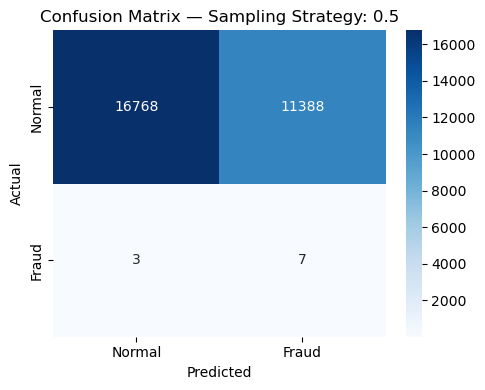

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------






In [47]:

random_state = 42


start = time.time()
X_train, X_test, y_train,  y_test = Xysplitter_SGD( df)
# Building pipeline
pipeline = Pipeline([('scaler', StandardScaler()), ('ocsvm', SGDOneClassSVM(random_state=random_state))])

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid_sgd_ocsvm,
    scoring = ocsvm_scorer,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)
print(f"\nBest params: {grid_search.best_params_}")
print(f"Best F1: {grid_search.best_score_:.4f}")

end = time.time()
print(f"Total runtime of the program on training data is {end - start:.4f} seconds")
    
start = time.time()
# Evaluate on test set
best_pipeline = grid_search.best_estimator_
y_pred_test = best_pipeline.predict(X_test)
y_pred_test = np.where(y_pred_test == 1, 1, 0)

metrics = evaluate_predictions(y_test, y_pred_test)
print(f"\nTEST DATASET METRICS")
print('-' * 20)
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
end = time.time()
print(f"Total runtime of the program on test data is {end - start:.4f} seconds\n")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Fraud']))

# Confusion Matrix   
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix — Sampling Strategy: {numm}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

    
print('-' * 150)
print('-' * 150)
print('\n')
print('\n')

In [48]:
# The features it decide was important in classifying fraud and none-fraud.
feature_weights = pd.DataFrame({'feature': X_train.columns, 'weight': best_pipeline.named_steps['ocsvm'].coef_})
feature_weights = feature_weights.sort_values('weight', ascending=False)
print(feature_weights[:10])

                                 feature    weight
37  third_party_recipient_sum_individual  0.000032
12                        breathing_aids  0.000005
0            avg_suplr_mdcr_pymt_amt_sum  0.000005
10                    tot_suplr_clms_max  0.000004
43    tot_suplr_srvcs_max_pctile_by_type  0.000004
7                    tot_suplr_srvcs_min  0.000004
33        bene_cc_ph_osteoporosis_v2_pct  0.000004
1            avg_suplr_mdcr_pymt_amt_min  0.000003
54    tot_suplr_benes_sum_zscore_by_type  0.000003
42    tot_suplr_benes_sum_pctile_by_type  0.000003


### Result:

This is the main problem. The weights are close to zero which means that the model is not sure/confident about the features importance in defining the normal boundry. 

This could be a SGDOCSVM issue as it only makes a linear boundry which as a consequence is not complex enough to capture complex patterns, i.e. too simple.

For this reason alone, further expansion of the hyper-parameter tuning is a waste of time as it would yield the same results. 

Overall, OCSVM with RandomUnderSampler had the best results so far, however it is important to remember that it is training with an extremely small dataset, from which a significant portion of information was lost. 

The results across all attempts do follow a consistant pattern, where precision and f1 scores are very low but recall is decently high. Most of time the model gives alot of false positives which in turn effects the evaluation metrics. 